# Calculate interannotator agreement


## Setup

- Enable `%autoreload` for immediate reflection of utils library changes
- Load credentials from the `.env` file
- Configure the environment and establish connection to the Argilla server

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import pandas as pd
import argilla as rg
import matplotlib.pyplot as plt
import seaborn as sns
from archaeo_ner_greek.utils import get_argilla_client, load_credentials_from_env, get_dataset_as_dataframe
from archaeo_ner_greek.utils import prepare_iaa_data, calculate_ner_iaa, calculate_label_iaa, analyze_iaa_discrepancies
from archaeo_ner_greek.logging_config import setup_logging
import logging

# 1. Setup logging
setup_logging()

# 2. Load configuration from .env
env_values = load_credentials_from_env()

# 3. Establish connection to Argilla
if env_values:
    client = get_argilla_client(env_values)
else:
    logging.warning("Missing configuration in .env file.")

2026-02-25 23:15:53,825 [INFO] root: Argilla: Logged in as prokopis with the role Role.owner


## Loading Annotations from Argilla

- Fetch the `archaeo_ner_greek` dataset
- Convert records into a Pandas DataFrame using `utils.py`
- Ensure all user responses (spans and suggestions) are included for analysis

In [5]:
# Define dataset and workspace
workspace_name = "atrium"
dataset_name = "atrium_csd_ner_annotations"
      
# Fetch the full dataframe with responses included
df = get_dataset_as_dataframe(
    client, 
    dataset_name=dataset_name, 
    workspace_name=workspace_name, 
    include_responses=True
)

## Data Exploration & Quality Check

- Visualize raw data before metric calculation
- Use custom CSS styling for wrapping Greek text and response dictionaries
- Manually verify annotation density and structure

In [6]:
# 1. Set display option to show full content instead of truncating (...)
pd.set_option('display.max_colwidth', None)

# 2. Select columns and apply styling for wrapping and vertical alignment
(df[["sentence_field", "responses"]].head(10).style
 .set_properties(**{
     'text-align': 'left',
     'white-space': 'pre-wrap',
     'vertical-align': 'top'
 })
 .set_table_styles([
     {'selector': 'th', 'props': [('font-weight', 'bold')]},
     {'selector': 'td.col0', 'props': [('width', '400px')]}, # Fixed width for sentence
     {'selector': 'td.col1', 'props': [('width', '600px')]}  # Fixed width for responses
 ])
)

,sentence_field,responses
0,"The uppermost 20 cm consist of very loose topsoil made up of light brown clayish silt with small stones, disturbed by agricultural activities, plant roots, and animal burrows. This layer lies above the two burials F1 (skeleton C603) and F2 (skeleton C623), the enclosure C601, the adjacent layers C605, C604, and C620, as well as the stone deposit at the southern limit of the trench (C611, C615). | [Previous notes on paper recordings : At the south limit of the trench. it supposed to be the inside area of trench set C604 and the redish brown area which is apart from south limit consider to be the ditch set C601 but it seems like a wall after excavated. And there is a skeleton at the 10m far from south wall, which set C603(F1) The machine clean from north to south.]""","[{'username': 'tim.evans', 'user_id': '4757b966-b9ae-4f55-9f8f-7cf0b05bb9af', 'values': [{'label': 'CONTEXT', 'start': 206, 'end': 213}, {'label': 'CONTEXT_ID', 'start': 214, 'end': 216}, {'label': 'CONTEXT_ID', 'start': 227, 'end': 231}, {'label': 'CONTEXT_ID', 'start': 237, 'end': 239}, {'label': 'CONTEXT_ID', 'start': 250, 'end': 254}, {'label': 'CONTEXT', 'start': 261, 'end': 270}, {'label': 'CONTEXT_ID', 'start': 271, 'end': 275}, {'label': 'CONTEXT_ID', 'start': 297, 'end': 301}, {'label': 'CONTEXT_ID', 'start': 303, 'end': 307}, {'label': 'CONTEXT_ID', 'start': 313, 'end': 317}, {'label': 'CONTEXT_ID', 'start': 385, 'end': 389}, {'label': 'CONTEXT_ID', 'start': 391, 'end': 395}, {'label': 'CONTEXT_ID', 'start': 520, 'end': 524}, {'label': 'CONTEXT', 'start': 602, 'end': 607}, {'label': 'CONTEXT_ID', 'start': 612, 'end': 616}, {'label': 'CONTEXT', 'start': 637, 'end': 641}, {'label': 'CONTEXT_ID', 'start': 725, 'end': 729}, {'label': 'CONTEXT_ID', 'start': 730, 'end': 732}, {'label': 'CONTEXT', 'start': 709, 'end': 713}, {'label': 'ARTEFACT', 'start': 218, 'end': 226}, {'label': 'ARTEFACT', 'start': 241, 'end': 249}, {'label': 'CONTEXT', 'start': 290, 'end': 296}, {'label': 'CONTEXT', 'start': 334, 'end': 347}, {'label': 'ARTEFACT', 'start': 674, 'end': 682}], 'status': }, {'username': 'stalexan', 'user_id': '521e8843-81c7-40a6-92cd-26b6b2a25544', 'values': [{'label': 'CONTEXT', 'start': 206, 'end': 213}, {'label': 'CONTEXT_ID', 'start': 214, 'end': 216}, {'label': 'CONTEXT_ID', 'start': 227, 'end': 231}, {'label': 'CONTEXT_ID', 'start': 237, 'end': 239}, {'label': 'CONTEXT_ID', 'start': 250, 'end': 254}, {'label': 'CONTEXT_ID', 'start': 271, 'end': 275}, {'label': 'CONTEXT_ID', 'start': 297, 'end': 301}, {'label': 'CONTEXT_ID', 'start': 303, 'end': 307}, {'label': 'CONTEXT_ID', 'start': 313, 'end': 317}, {'label': 'CONTEXT', 'start': 377, 'end': 383}, {'label': 'CONTEXT_ID', 'start': 385, 'end': 389}, {'label': 'CONTEXT_ID', 'start': 391, 'end': 395}, {'label': 'CONTEXT', 'start': 464, 'end': 470}, {'label': 'CONTEXT', 'start': 509, 'end': 515}, {'label': 'CONTEXT_ID', 'start': 520, 'end': 524}, {'label': 'CONTEXT', 'start': 602, 'end': 607}, {'label': 'CONTEXT_ID', 'start': 612, 'end': 616}, {'label': 'CONTEXT', 'start': 637, 'end': 641}, {'label': 'CONTEXT_ID', 'start': 725, 'end': 729}, {'label': 'CONTEXT_ID', 'start': 730, 'end': 732}, {'label': 'CONTEXT', 'start': 709, 'end': 713}, {'label': 'CONTEXT', 'start': 340, 'end': 347}, {'label': 'ARTEFACT', 'start': 674, 'end': 682}, {'label': 'ARTEFACT', 'start': 218, 'end': 226}, {'label': 'ARTEFACT', 'start': 241, 'end': 249}], 'status': }, {'username': 'stalexan', 'user_id': '521e8843-81c7-40a6-92cd-26b6b2a25544', 'values': 'ok', 'status': }]"
1,"This context was discovered after the removal of C214. It has a very dark ashy brown color with fine texture. It includes traces of burnt material, possibly wall, as we found a significant amount of CBM with burn marks on it. Also, we found 3 sherds (rim, body and bottom) of the same bowl (2 of them-rim&body- a align with each other). They are of something color with red traces on the inside surface and signs of extended use It's a ty

## Structuring Data for IAA

- Transform raw Argilla responses into entity triplets `(start, end, label)`
- Group annotations by user using the `prepare_iaa_data` utility
- Identify sentences ready for comparison (2+ annotators) versus those requiring more work

In [8]:
# 1. Prepare data for agreement analysis
iaa_results = prepare_iaa_data(df)
iaa_ready = iaa_results["ready"]

# 2. Map annotators for consistent reporting (A=stalexan, B=sasi.dimopoulou)
annotator_a = "stalexan"
annotator_b = "tim.evans"
print(f"Mapping: A = {annotator_a}, B = {annotator_b}")

# 3. Report annotation status
print(f"✅ Sentences ready for IAA: {len(iaa_ready)}")
print(f"⚠️  Missing teammates (only 1 annotator): {len(iaa_results['missing_teammate'])}")
print(f"❌ Unannotated sentences: {len(iaa_results['unannotated'])}")

Mapping: A = stalexan, B = tim.evans
✅ Sentences ready for IAA: 90
⚠️  Missing teammates (only 1 annotator): 0
❌ Unannotated sentences: 0


## Pairwise Agreement Report (Global)

- Calculate high-level consistency metrics between annotator pairs
- **Sentence Match %**: Perfect sentence set-equality (including sentences with zero entities)
- **Span F1-Score**: Standard NER benchmark for entity segment overlap

In [9]:
# Calculate and display pairwise agreement report
iaa_report = calculate_ner_iaa(iaa_ready)
iaa_report

,Annotator Pair,Sentences Compared,Perfect Matches,Sentence Match %,Span F1-Score
0,stalexan ↔ tim.evans,90,8,8.9%,0.674


## Label-Specific Agreement Breakdown

- Breakdown agreement metrics (F1-score) for each individual label
- Identify categories where annotation guidelines may require clarification or additional examples

In [10]:
# Calculate and display per-label agreement statistics using consistent A/B mapping
label_report = calculate_label_iaa(iaa_ready, annotators=[annotator_a, annotator_b])
label_report

,Label,Both,Only in A (stalexan),Only in B (tim.evans),F1-Score
0,LOCATION,1,0,0,1.0000
1,CONTEXT_ID,308,33,10,0.9347
2,ARTEFACT,135,134,62,0.5794
3,PERIOD,13,15,4,0.5778
4,FEATURE,2,1,2,0.5714
5,CONTEXT,175,207,92,0.5393
6,SPECIES,6,13,3,0.4286
7,MATERIAL,3,43,3,0.1154
8,OVERALL,643,446,176,0.6740


## Discrepancy Analysis

- Distinguish between classification errors (same span, different label) and boundary errors (overlapping spans)
- Quantify total misses where an entity was identified by only one annotator

In [11]:
# Categorize disagreements into specific error types
discrepancy_report = analyze_iaa_discrepancies(iaa_ready, annotators=[annotator_a, annotator_b])
discrepancy_report

,Count
Exact Matches,642.00
Label Mismatches,9.00
Boundary Disagreements,110.00
Total Misses (A only),328.00
Total Misses (B only),79.00
Boundary Char Diff (Avg),5.95


## Visualizations for Annotator Feedback

- Generate graphical representations of agreement and disagreement
- Compare performance across different entity categories
- Visualize the distribution of specific error types to inform guideline refinement

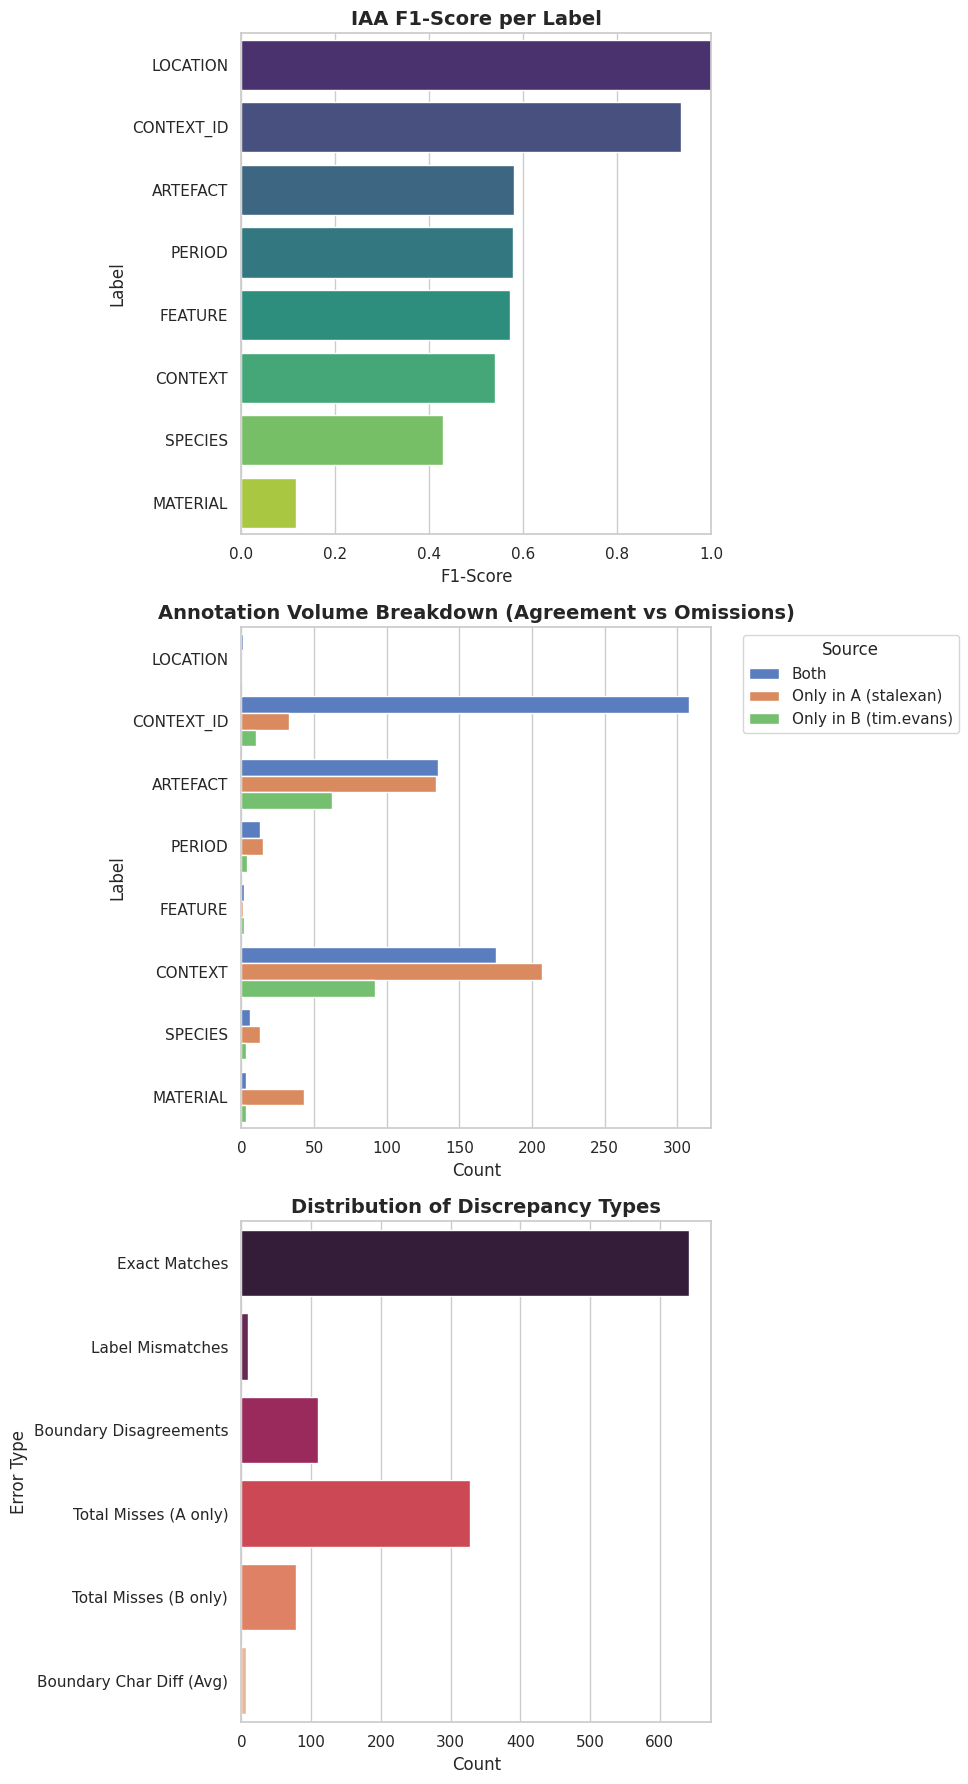

In [12]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# 1. Label F1-Scores
label_data_clean = label_report[label_report["Label"] != "OVERALL"].sort_values("F1-Score", ascending=False)
sns.barplot(data=label_data_clean, x="F1-Score", y="Label", ax=axes[0], palette="viridis")
axes[0].set_title("IAA F1-Score per Label", fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1)

# 2. Agreement vs Disagreement Volume
label_counts = label_data_clean.melt(id_vars="Label", value_vars=["Both", f"Only in A ({annotator_a})", f"Only in B ({annotator_b})"], 
                                    var_name="Category", value_name="Count")
sns.barplot(data=label_counts, x="Count", y="Label", hue="Category", ax=axes[1], palette="muted")
axes[1].set_title("Annotation Volume Breakdown (Agreement vs Omissions)", fontsize=14, fontweight='bold')
axes[1].legend(title="Source", bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Discrepancy Types Distribution
discrepancy_data = discrepancy_report.reset_index()
discrepancy_data.columns = ["Error Type", "Count"]
sns.barplot(data=discrepancy_data, x="Count", y="Error Type", ax=axes[2], palette="rocket")
axes[2].set_title("Distribution of Discrepancy Types", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
iaa_report

,Annotator Pair,Sentences Compared,Perfect Matches,Sentence Match %,Span F1-Score
0,stalexan ↔ tim.evans,90,8,8.9%,0.674


In [14]:
label_report

,Label,Both,Only in A (stalexan),Only in B (tim.evans),F1-Score
0,LOCATION,1,0,0,1.0000
1,CONTEXT_ID,308,33,10,0.9347
2,ARTEFACT,135,134,62,0.5794
3,PERIOD,13,15,4,0.5778
4,FEATURE,2,1,2,0.5714
5,CONTEXT,175,207,92,0.5393
6,SPECIES,6,13,3,0.4286
7,MATERIAL,3,43,3,0.1154
8,OVERALL,643,446,176,0.6740


In [15]:
discrepancy_report

,Count
Exact Matches,642.00
Label Mismatches,9.00
Boundary Disagreements,110.00
Total Misses (A only),328.00
Total Misses (B only),79.00
Boundary Char Diff (Avg),5.95
